ВАЖНОЕ ЗАМЕЧАНИЕ: ЕСЛИ ХОЧЕТСЯ ПОСМОТРЕТЬ КАК РАБОТАЕТ НА СВОЁМ ИЗОБРАЖЕНИИ, ТО ПРОСТО ЗАГРУЗИТЕ ФАЙЛ В ПАПКУ `test_images` И ВЫБЕРИТЕ В ПОЛЕ `mask_image_number` нужный ID



Теперь это не колаб, так просто не получится.....

### Настройка системы, установка необходимых библиотек

Все данные на гугл диске, качаем оттуда модель и тестовые семплы

In [4]:
import gdown
gdown.download_folder("https://drive.google.com/drive/folders/1KizYc5lkyL1itwhEmZ9SBDKix-O9tZ8Q?usp=sharing", quiet=True)
gdown.download("https://drive.google.com/uc?id=19rTFMv99VVBX04fWtU1LGL0E1dwZEpow", quiet=True)

'cellpose_sam_aug_epoch_0045'

In [5]:
from IPython.display import clear_output

!git clone https://github.com/Tencent-Hunyuan/Hunyuan3D-2.git

!pip install git+https://www.github.com/mouseland/cellpose.git

clear_output()

In [6]:
%cd /kaggle/working/Hunyuan3D-2

!pip install -r requirements.txt
!pip install -e .

clear_output()

In [7]:
import cv2
import time
import os
import numpy as np
import math
from pathlib import Path
from natsort import natsorted
import torch
from transformers import CLIPImageProcessor, CLIPVisionModel
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from PIL import Image
import matplotlib.pyplot as plt
from cellpose import models, core, io, plot

import ipywidgets as widgets
from IPython.display import display


from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline

2026-04-23 15:25:18.843373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776957919.053024      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776957919.114069      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776957919.633165      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776957919.633207      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776957919.633210      55 computation_placer.cc:177] computation placer alr

Подгружаем модель сегментации на GPU

In [8]:
io.logger_setup()

model = models.CellposeModel(pretrained_model='/kaggle/working/cellpose_sam_aug_epoch_0045', gpu=True)

creating new log file
2026-04-23 15:27:03,346 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-23 15:27:03,347 [INFO] 
cellpose version: 	4.1.2.dev16+g71e7e8872 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.8.0+cu126
2026-04-23 15:27:03,607 [INFO] ** TORCH CUDA version installed and working. **
2026-04-23 15:27:03,608 [INFO] >>>> using GPU (CUDA)
2026-04-23 15:27:06,350 [INFO] >>>> loading model /kaggle/working/cellpose_sam_aug_epoch_0045


Функция для вырезания частиц по их бинарным маскам

In [9]:
def cutouts_from_label_mask(
    im: np.ndarray,            # HxWx3 uint8, RGB
    label_mask: np.ndarray,    # HxW uint16/uint32, 0=фон, 1..K = id объектов
    crop_to_mask: bool = True,
    min_pixels: int = 100,
):
    im_rgb = Image.fromarray(im).convert("RGBA")

    ids = np.unique(label_mask)
    ids = ids[ids != 0]

    results = []
    for obj_id in ids:
        bin_mask = (label_mask == obj_id).astype(np.uint8) * 255
        if np.count_nonzero(bin_mask) < min_pixels:
            continue

        alpha = Image.fromarray(bin_mask).convert("L")  # 0..255

        cutout = im_rgb.copy()
        cutout.putalpha(alpha)  # альфа = маска

        bbox = None
        if crop_to_mask:
            bbox = alpha.getbbox()
            if bbox is None:
                continue
            cutout = cutout.crop(bbox)

        results.append((int(obj_id), cutout, bbox))

    return results

Пробегаемся по всем изоюражениям в папке

In [10]:
dir = "/kaggle/working/test_images"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

image_ext = ".jpg"

files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

imgs = []
for i in files:
    imgs.append(io.imread(i))

print("images in array: ", len(imgs))

10 images in folder:
611.jpg
721.jpg
772.jpg
821.jpg
909(20nm).jpg
992_1(150nm).jpg
1026.jpg
1029.jpg
1076.jpg
1152.jpg
images in array:  10


### Погнали тестить

#### СЕГМЕНТАЦИЯ ЧАСТИЦ

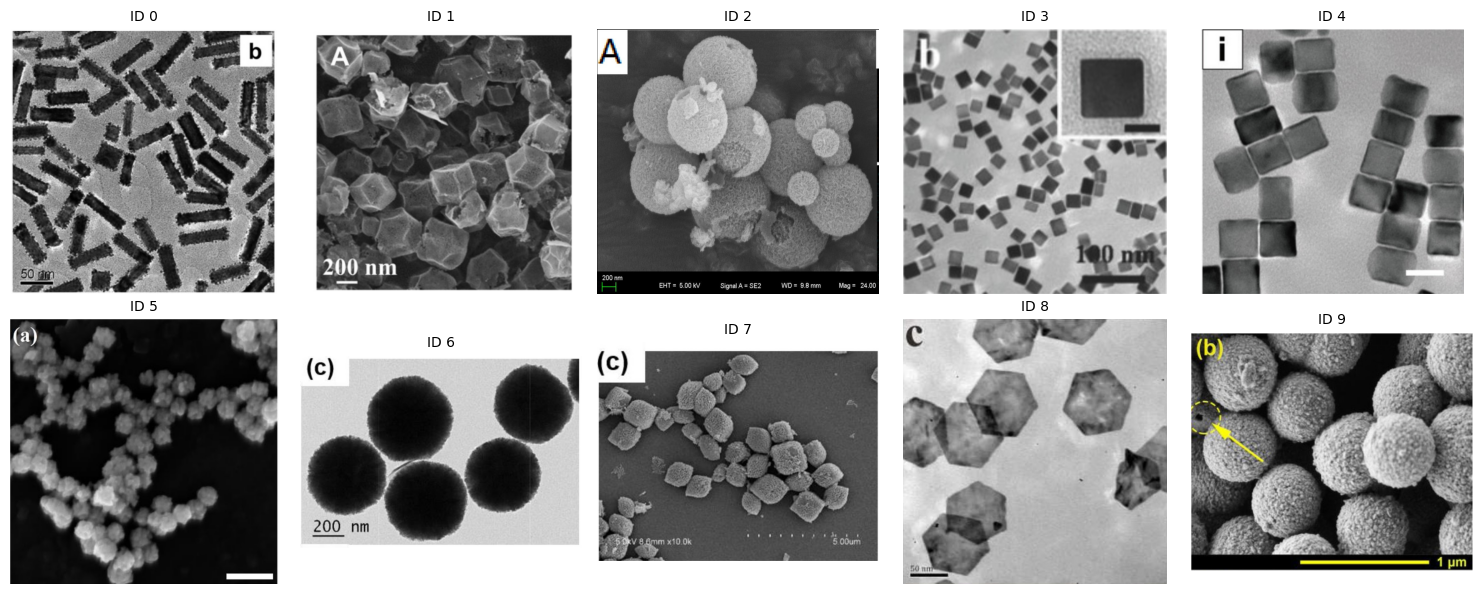

In [11]:
n = len(imgs)
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(3*cols, 3*rows))
for i, img in enumerate(imgs):
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(img)
    ax.set_title(f"ID {i}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
masks_pred, flows, styles = model.eval(imgs, niter=1000)

2026-04-23 15:28:14,773 [INFO] 100%|##########| 10/10 [01:01<00:00,  6.12s/it]


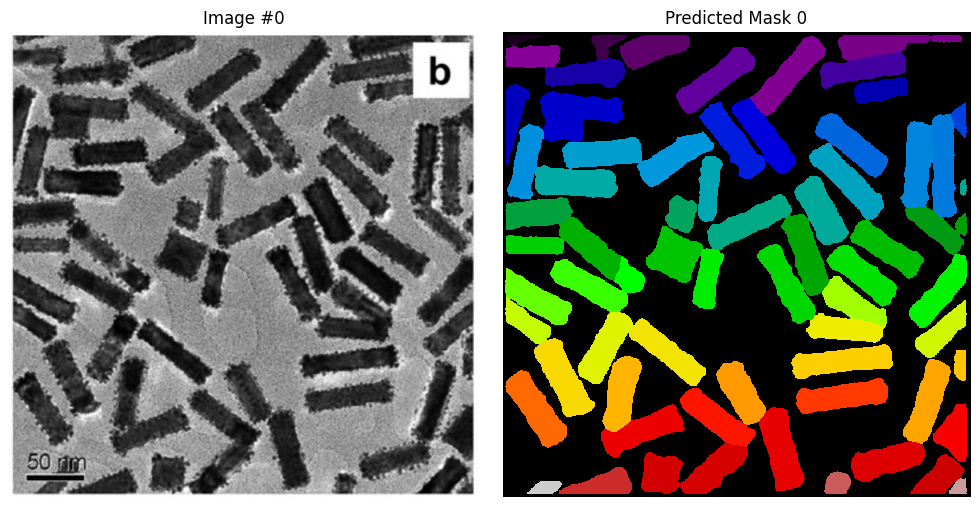

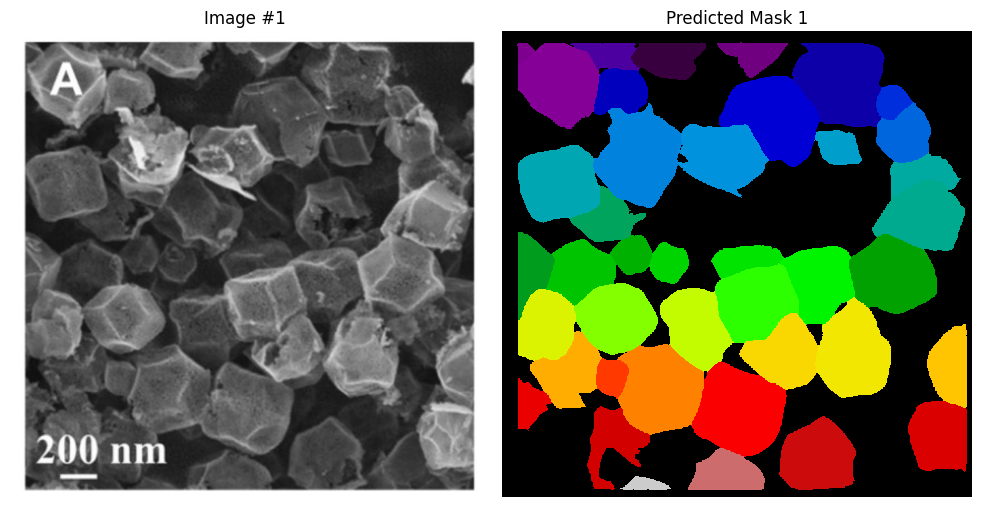

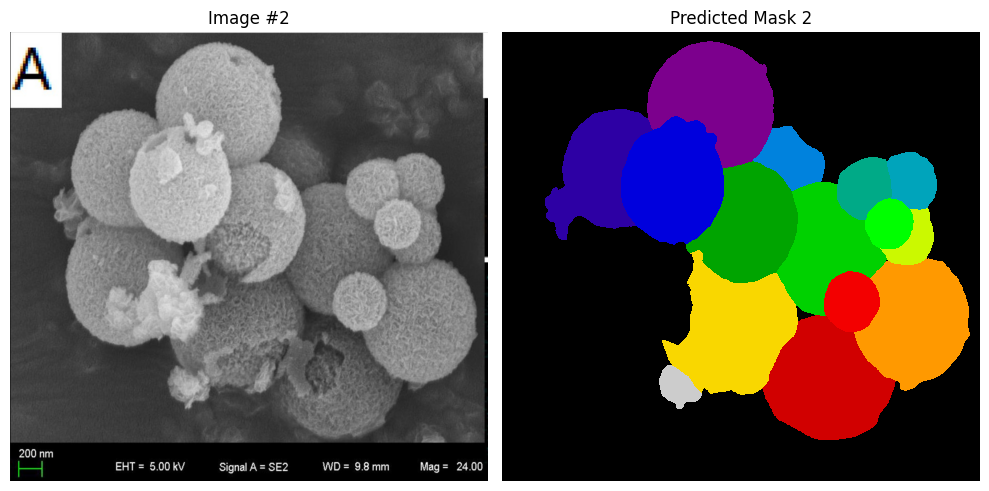

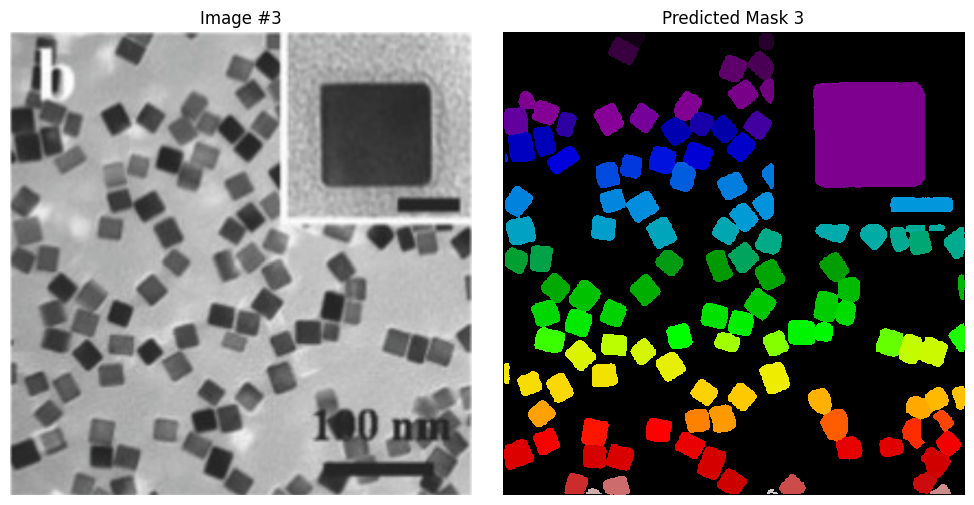

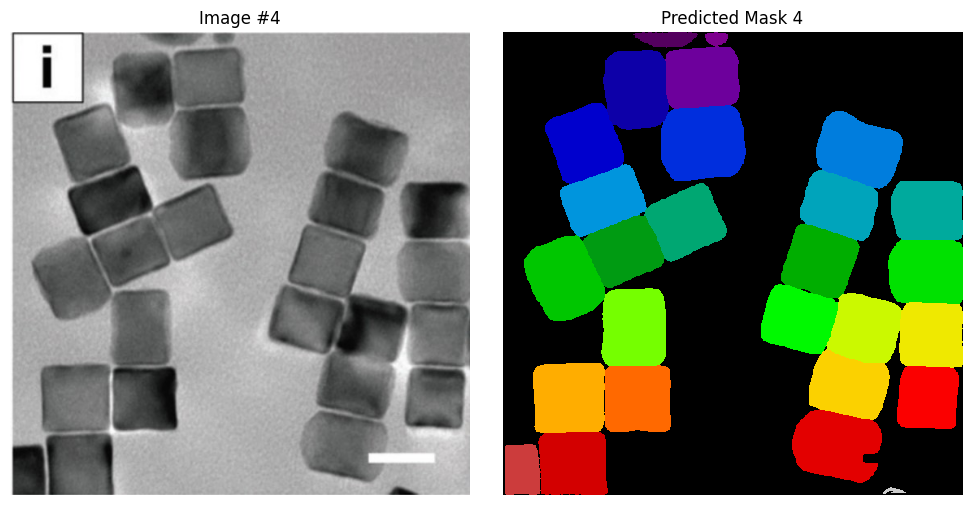

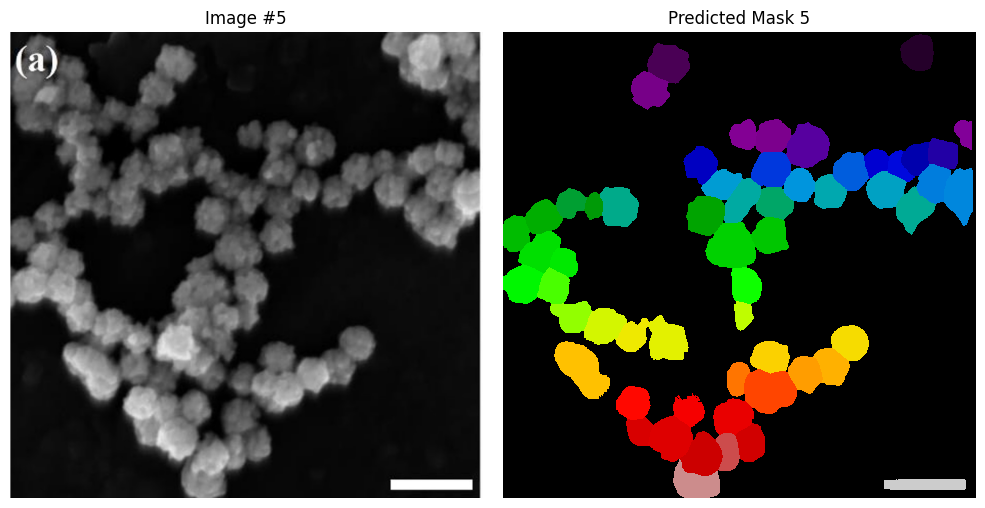

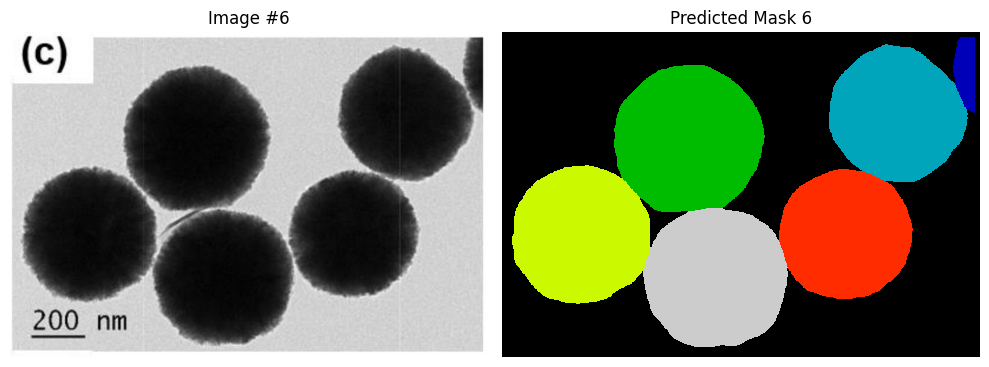

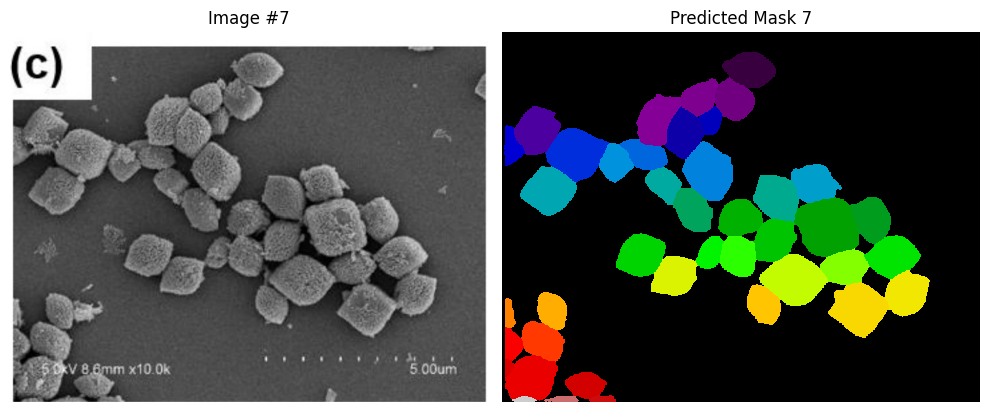

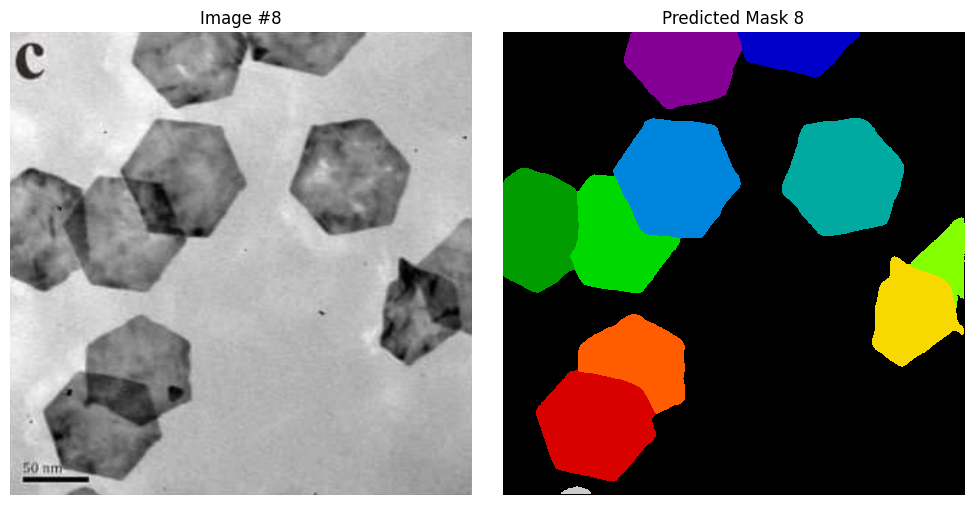

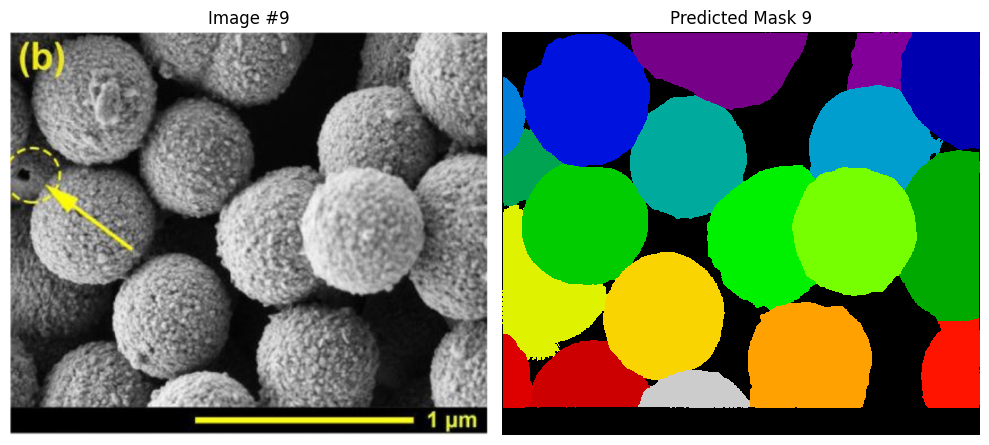

In [13]:
for i in range(len(imgs)):

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    show_img = imgs[i].squeeze()
    ax[0].imshow(show_img)
    ax[0].set_title(f"Image #{i}")
    ax[0].axis('off')

    ax[1].imshow(masks_pred[i], cmap='nipy_spectral', interpolation='nearest')
    ax[1].set_title(f"Predicted Mask {i}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

#### Вырезаем по маске изображения

Для данного примера изображения идут с индексами от 0 до 9. Выбираем ползунком любое которое понравилось

In [14]:
mask_image_number = widgets.IntSlider(
    value=8,
    min=0,
    max=len(masks_pred)-1,
    step=1,
    description="mask idx",
    continuous_update=False
)
display(mask_image_number)

IntSlider(value=8, continuous_update=False, description='mask idx', max=9)

In [15]:
mask_image_number = mask_image_number.value

label_mask = masks_pred[mask_image_number]
img = imgs[mask_image_number]
cutouts = cutouts_from_label_mask(img, label_mask, crop_to_mask=True, min_pixels=100)

print("N objects:", len(cutouts))

N objects: 11


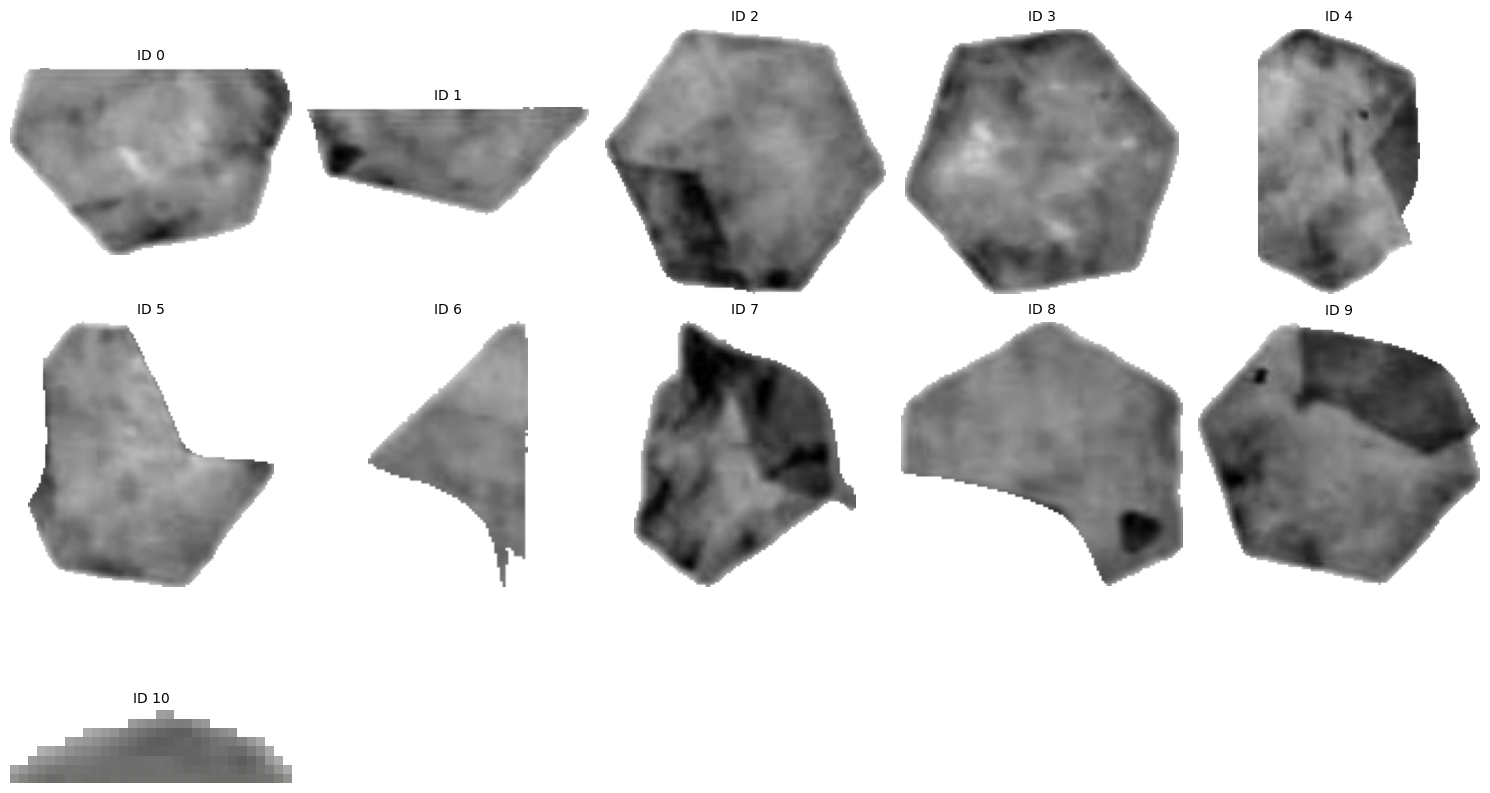

In [16]:
n = len(cutouts)
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(3*cols, 3*rows))
for i, (obj_id, cutout_pil, bbox) in enumerate(cutouts):
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(cutout_pil)
    ax.set_title(f"ID {i}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

Если хотим сохранить в отдельный файл верезанную частицу

In [17]:
cutout_to_png = widgets.IntSlider(
    value=2,
    min=0,
    max=len(cutouts)-1,
    step=1,
    description="Cutout to PNG",
    continuous_update=False
)
display(cutout_to_png)

IntSlider(value=2, continuous_update=False, description='Cutout to PNG', max=10)

In [18]:
cutout_png = cutout_to_png.value

save_dir_cut = '/kaggle/working/tmp/results/'
os.makedirs(save_dir_cut, exist_ok=True)
obj_id, cutout_rgba_pil, bbox = cutouts[cutout_png]
cutout_rgba_pil.save(f"{save_dir_cut}/obj_{obj_id}.png")

#### КЛАСТЕРИЗАЦИЯ МОМЕНТ

In [19]:
all_cutouts = []
all_meta = []

for i, (obj_id, cutout_rgba_pil, bbox) in enumerate(cutouts):
    all_cutouts.append(cutout_rgba_pil)
    all_meta.append((i, obj_id, bbox))

print("Total particles:", len(all_cutouts))

Total particles: 11


CLIP нужен для создания эмбеддингов, по которому мы будем  мерить визуальное сходство и делать кластеризацию

In [20]:
clip_processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-large-patch14", use_fast=True)
clip_vision = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14").eval()

features = []
with torch.no_grad():
    for cutout_rgba in all_cutouts:
        img_rgb = cutout_rgba.convert("RGB")
        inputs = clip_processor(img_rgb, return_tensors="pt")
        outputs = clip_vision(**inputs)
        feat = outputs.last_hidden_state[0, 0, :].cpu().numpy()
        features.append(feat)

features = np.asarray(features)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

стандартизация и подбор кластеров

In [21]:
X = (features - features.mean(0)) / (features.std(0) + 1e-8)

n = len(X)
k_range = range(2, min(20, n))
scores = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    scores.append(silhouette_score(X, labels))

best_k = list(k_range)[int(np.argmax(scores))]
print("best_k:", best_k, "best_sil:", float(np.max(scores)))

best_k: 3 best_sil: 0.17634694278240204


In [22]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

representatives = {}
for c in range(best_k):
    idx = np.where(labels == c)[0]
    if len(idx) == 0:
        continue
    d = np.linalg.norm(X[idx] - centers[c], axis=1)
    representatives[c] = idx[int(np.argmin(d))]

print("Representatives:", representatives)

Representatives: {0: np.int64(3), 1: np.int64(7), 2: np.int64(10)}


In [23]:
rep_items = []
for cluster_id, img_num in representatives.items():
    rep_img = all_cutouts[img_num]
    rep_meta = all_meta[img_num]
    rep_items.append((cluster_id, img_num, rep_img, rep_meta))

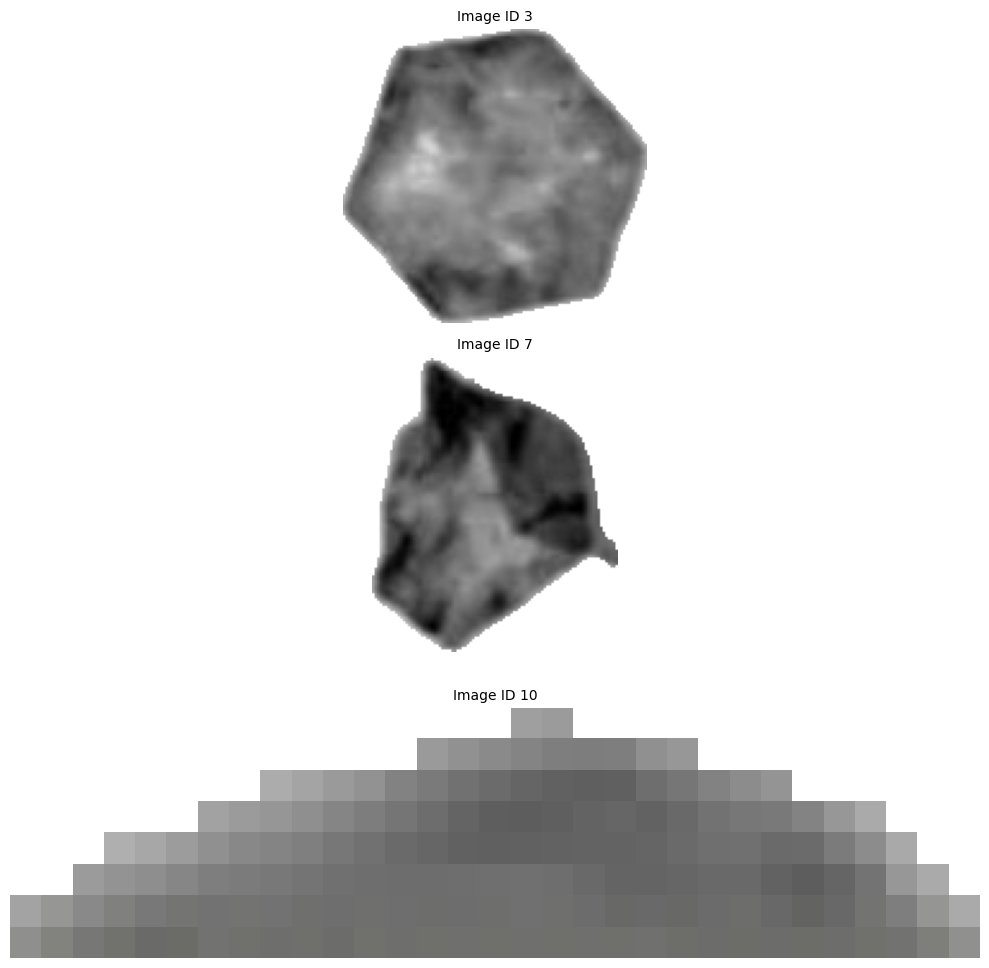

In [24]:
n = len(rep_items)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(10, 10))
for i, (cluster_id, img_num, rep_img, rep_meta) in enumerate(rep_items):
    # rep_img.save(f"cluster_{cluster_id}_rep_{gi}.png")
    ax = plt.subplot(cols, rows, i+1)
    ax.imshow(rep_img)
    ax.set_title(f"Image ID {img_num}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

Выберите любое изображение частицы ползунком, отсчёт начинается с 0

In [25]:
image_to_3D = widgets.IntSlider(
    value=0,
    min=0,
    max=len(representatives)-1,
    step=1,
    description="CELL to 3D",
    continuous_update=False
)
display(image_to_3D)

IntSlider(value=0, continuous_update=False, description='CELL to 3D', max=2)

In [26]:
image_3D = image_to_3D.value

model_path = "tencent/Hunyuan3D-2"
subfolder = 'hunyuan3d-dit-v2-0-turbo'
pipeline_shapegen = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(model_path, subfolder=subfolder, use_safetensors=True)

pipeline_shapegen.enable_flashvdm()

image = rep_items[image_3D][2]

def run():
    return pipeline_shapegen(
        image=image,
        num_inference_steps=5,
        # octree_resolution=380,
        # num_chunks=200000,
        generator=torch.manual_seed(12345),
        output_type='trimesh'
    )[0]


save_dir = '/kaggle/working/tmp/results/'
os.makedirs(save_dir, exist_ok=True)

for it in range(1):
    start_time = time.time()
    mesh = run()
    print("--- %s seconds ---" % (time.time() - start_time))
    mesh.export(f'{save_dir}/run_{it}.glb')

# mesh = pipeline_shapegen(image=image)[0]
# mesh.export("obj_2_turbo.glb")

2026-04-23 15:28:42,867 - hy3dgen.shapgen - INFO - Try to load model from local path: /root/.cache/hy3dgen/tencent/Hunyuan3D-2/hunyuan3d-dit-v2-0-turbo


2026-04-23 15:28:42,867 [INFO] Try to load model from local path: /root/.cache/hy3dgen/tencent/Hunyuan3D-2/hunyuan3d-dit-v2-0-turbo


2026-04-23 15:28:42,868 - hy3dgen.shapgen - INFO - Model path not exists, try to download from huggingface


2026-04-23 15:28:42,868 [INFO] Model path not exists, try to download from huggingface


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

2026-04-23 15:29:57,955 [INFO] Loading model from /root/.cache/huggingface/hub/models--tencent--Hunyuan3D-2/snapshots/9cd649ba6913f7a852e3286bad86bfa9a2d83dcf/hunyuan3d-vae-v2-0-turbo/model.fp16.safetensors
PointCrossAttentionEncoder INFO: pc_sharpedge_size is given, using pc_size=5120, pc_sharpedge_size=5120


Diffusion Sampling:: 100%|██████████| 5/5 [00:03<00:00,  1.60it/s]
2026-04-23 15:30:04,284 - hy3dgen.shapgen - INFO - FlashVDMVolumeDecoding Resolution: [95, 190, 380]


2026-04-23 15:30:04,284 [INFO] FlashVDMVolumeDecoding Resolution: [95, 190, 380]


FlashVDM Volume Decoding: 100%|██████████| 64/64 [00:00<00:00, 360.58it/s]
/kaggle/working/Hunyuan3D-2/hy3dgen/shapegen/models/autoencoders/volume_decoders.py:81: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  sliced = padded[slice_dims]


--- 9.87265157699585 seconds ---


In [26]:
import torch
from PIL import Image

from hy3dgen.rembg import BackgroundRemover
from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline, FaceReducer, FloaterRemover, DegenerateFaceRemover

image_3D = image_to_3D.value

def image_to_3d():
    rembg = BackgroundRemover()
    model_path = 'tencent/Hunyuan3D-2'

    image = rep_items[image_3D][2]

    if image.mode == 'RGB':
        image = rembg(image)

    pipeline = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(model_path)

    mesh = pipeline(image=image, num_inference_steps=30, mc_algo='mc',
                    generator=torch.manual_seed(2025))[0]
    mesh = FloaterRemover()(mesh)
    mesh = DegenerateFaceRemover()(mesh)
    mesh = FaceReducer()(mesh)
    mesh.export('mesh.glb')

    try:
        from hy3dgen.texgen import Hunyuan3DPaintPipeline
        pipeline = Hunyuan3DPaintPipeline.from_pretrained(model_path)
        mesh = pipeline(mesh, image=image)
        mesh.export('texture.glb')
    except Exception as e:
        print(e)
        print('Please try to install requirements by following README.md')


def text_to_3d(prompt='a car'):
    rembg = BackgroundRemover()
    t2i = HunyuanDiTPipeline('Tencent-Hunyuan/HunyuanDiT-v1.1-Diffusers-Distilled')
    model_path = 'tencent/Hunyuan3D-2'
    i23d = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(model_path)

    image = t2i(prompt)
    image = rembg(image)
    mesh = i23d(image, num_inference_steps=30, mc_algo='mc')[0]
    mesh = FloaterRemover()(mesh)
    mesh = DegenerateFaceRemover()(mesh)
    mesh = FaceReducer()(mesh)
    mesh.export('t2i_demo.glb')


def image_to_3d_fast():
    rembg = BackgroundRemover()
    model_path = 'tencent/Hunyuan3D-2'

    image = rep_items[image_3D][2]

    if image.mode == 'RGB':
        image = rembg(image)

    pipeline = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(
        model_path,
        subfolder='hunyuan3d-dit-v2-0-fast',
        variant='fp16'
    )

    mesh = pipeline(image=image, num_inference_steps=30, mc_algo='mc',
                    generator=torch.manual_seed(2025))[0]
    mesh = FloaterRemover()(mesh)
    mesh = DegenerateFaceRemover()(mesh)
    mesh = FaceReducer()(mesh)
    mesh.export('mesh.glb')


if __name__ == '__main__':
    image_to_3d_fast()
    # image_to_3d()
    # text_to_3d()

Try to load model from local path: /root/.cache/hy3dgen/tencent/Hunyuan3D-2/hunyuan3d-dit-v2-0-fast
Model path not exists, try to download from huggingface


Fetching 82 files:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-23 09:24:23,223 [INFO] Loading model from /root/.cache/huggingface/hub/models--tencent--Hunyuan3D-2/snapshots/9cd649ba6913f7a852e3286bad86bfa9a2d83dcf/hunyuan3d-dit-v2-0-fast/model.fp16.ckpt
Using border_ratio from init: 0.15
Using guidance embed with scale 7.5


MC Level 0.0 Implicit Function:: 100%|██████████| 7134/7134 [02:25<00:00, 49.01it/s]


Переходим на сайт https://nexreality.io/glb-viewer/  скачиваем из папки `/kaggle/working/tmp/results` артефакт и смотрим результат

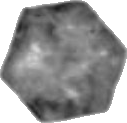

In [28]:
rep_items[0][2]

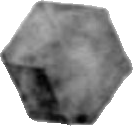

In [27]:
cutouts[2][1]

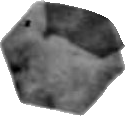

In [41]:
cutouts[9][1]

In [46]:
from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline, FaceReducer, FloaterRemover, DegenerateFaceRemover
pipeline = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(
    'tencent/Hunyuan3D-2mv',
    subfolder='hunyuan3d-dit-v2-mv-turbo',
    use_safetensors=True,
    device='cuda'
)
mesh = pipeline(
    image={
        "front": cutouts[2][1],
        "back": rep_items[0][2]
    },
    num_inference_steps=30,
    octree_resolution=380,
    guidance_scale=7.0,   
    mc_algo='mc', 
    generator=torch.manual_seed(12345),
    output_type='trimesh'
)[0]
mesh = FloaterRemover()(mesh)
mesh = DegenerateFaceRemover()(mesh)
mesh = FaceReducer()(mesh)
mesh.export('mesh.glb')
clear_output()